<a href="https://colab.research.google.com/github/rtajeong/M3_2026/blob/main/lab38_hyperparameter_rev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperparameter Tuning
- to choose a set of optimal hyperparameters for a learning algorithm
- example case: Bike Renting Analysis problem (from kaggle)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn import svm
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import make_scorer
%matplotlib inline

## Dataset 로드
- Kaggle 에서 직접 가져와야 함.
- 0 단계:
  - Kaggle 계정에서 API Token 발급 → kaggle.json 파일 다운로드 (또는 직접 kaggle.json 파일 생성)
  - Colab에 kaggle.json 업로드 후 아래 코드 진행.
- 1단계: 캐글 웹사이트에서 대회 규칙 동의하기
  - Kaggle Bike Sharing Demand 대회 페이지에 접속하여 로그인한다. (https://www.kaggle.com/datasets/abdullapathan/bikesharingdemand)
  - Rules 탭 또는 Data 탭으로 이동하여 'Join Competition' 또는 'Understand Rules' 버튼을 누르고 규칙에 동의한다.
- 2단계: 코랩에서 공식 대회 명령어로 다운로드하기
  - 동의를 완료했다면 노트북에서 datasets 대신 competitions 명령어를 사용해야 한다. 가장 직관적인 명령어는 다음과 같다.
  ```
  !kaggle competitions download -c bike-sharing-demand
  ```
- 사이트에서 직접 다운로드 가능 (미리 다운로드하여 여러분에게 제공하겠음)


In [25]:
train = pd.read_csv("bike_train.csv")
train.dtypes

,0
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [26]:
train.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40


## Data read and Preprocessing

In [27]:
train = pd.read_csv("bike_train.csv", parse_dates=["datetime"])
train.dtypes

,0
datetime,datetime64[ns]
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [28]:
train.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [29]:
train.shape     # (10886, 12)

(10886, 12)

In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


- decompose 'datetime' feature

In [31]:
train["d-year"] = train["datetime"].dt.year
train["d-month"] = train["datetime"].dt.month
train["d-day"] = train["datetime"].dt.day
train["d-hour"] = train["datetime"].dt.hour
train["d-minute"] = train["datetime"].dt.minute
train["d-second"] = train["datetime"].dt.second

In [32]:
train["d-dayofweek"] = train["datetime"].dt.dayofweek   # monday(0), ... sunday(6)

In [33]:
train[["datetime", "d-year", "d-month", "d-day", "d-hour",
       "d-minute", "d-second", "d-dayofweek"]].head()

,datetime,d-year,d-month,d-day,d-hour,d-minute,d-second,d-dayofweek
0,2011-01-01 00:00:00,2011,1,1,0,0,0,5
1,2011-01-01 01:00:00,2011,1,1,1,0,0,5
2,2011-01-01 02:00:00,2011,1,1,2,0,0,5
3,2011-01-01 03:00:00,2011,1,1,3,0,0,5
4,2011-01-01 04:00:00,2011,1,1,4,0,0,5


<Axes: xlabel='d-hour', ylabel='count'>

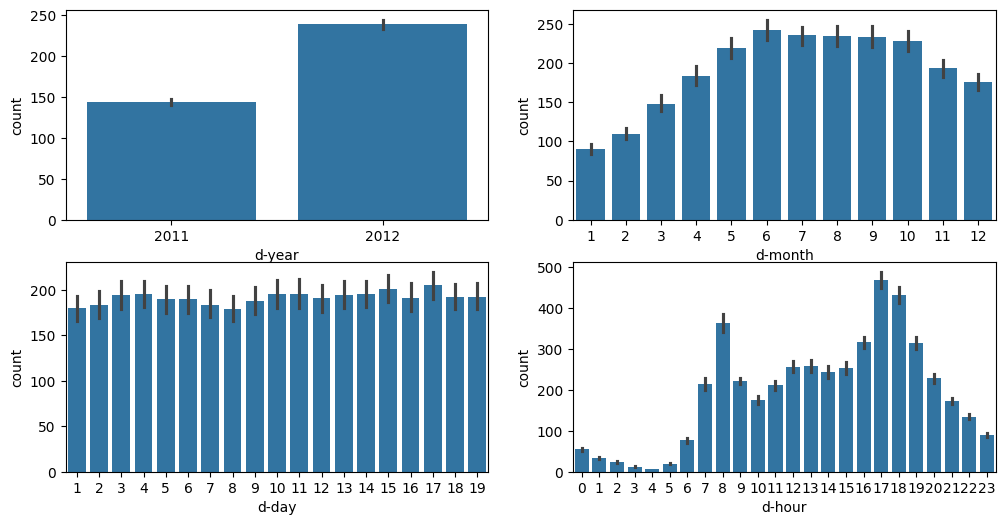

In [34]:
figure, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
figure.set_size_inches(12, 6)

sns.barplot(data=train, x="d-year", y="count", ax=ax1)
sns.barplot(data=train, x="d-month", y="count", ax=ax2)
sns.barplot(data=train, x="d-day", y="count", ax=ax3)
sns.barplot(data=train, x="d-hour", y="count", ax=ax4)

## Data Analysis

#### average numbers of rentals by hour (weekdays and weekends)
- pointplot(): 범주형 변수별 통계량(주로 평균)과 그 불확실성(오차막대)을 점과 선으로 표현하여 그룹 간 차이와 추세를 시각화하는 그래프
- barplot() 은 막대의 높이로 평균 표시.
- pointplot()은 값의 변화 추세를 보기 쉽고, barplot()은 크기 비교가 직관적이다.


<Axes: xlabel='d-hour', ylabel='count'>

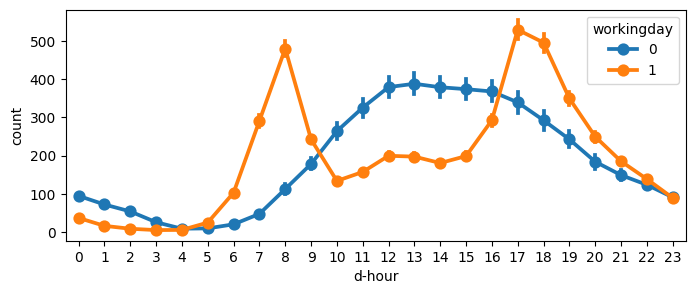

In [36]:
plt.figure(figsize=(8,3))
sns.pointplot(data=train, x="d-hour", y="count", hue="workingday")

#### average number of rentals (weekdays)
- dayofweek: return the day of the week. (0: 월요일)

In [37]:
print(train.shape)
train[["datetime", "d-dayofweek"]].head()

(10886, 19)


,datetime,d-dayofweek
0,2011-01-01 00:00:00,5
1,2011-01-01 01:00:00,5
2,2011-01-01 02:00:00,5
3,2011-01-01 03:00:00,5
4,2011-01-01 04:00:00,5


<Axes: xlabel='d-hour', ylabel='count'>

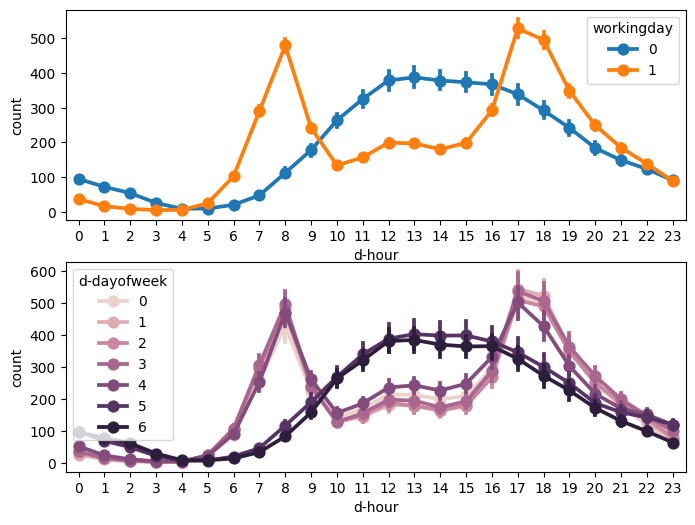

In [40]:
figure, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)
figure.set_size_inches(8, 6)

sns.pointplot(data=train, x="d-hour", y="count", hue="workingday", ax=ax1)
sns.pointplot(data=train, x="d-hour", y="count", hue="d-dayofweek", ax=ax2)

#### generating a new feature by combining year and month

In [41]:
def concatenate_year_month(datetime):
    return "{0}-{1}".format(datetime.year, datetime.month)

train["d-year_month"] = train["datetime"].apply(concatenate_year_month)

print(train.shape)
train[["datetime", "d-year_month"]].head()

(10886, 20)


,datetime,d-year_month
0,2011-01-01 00:00:00,2011-1
1,2011-01-01 01:00:00,2011-1
2,2011-01-01 02:00:00,2011-1
3,2011-01-01 03:00:00,2011-1
4,2011-01-01 04:00:00,2011-1


<Axes: xlabel='d-year_month', ylabel='count'>

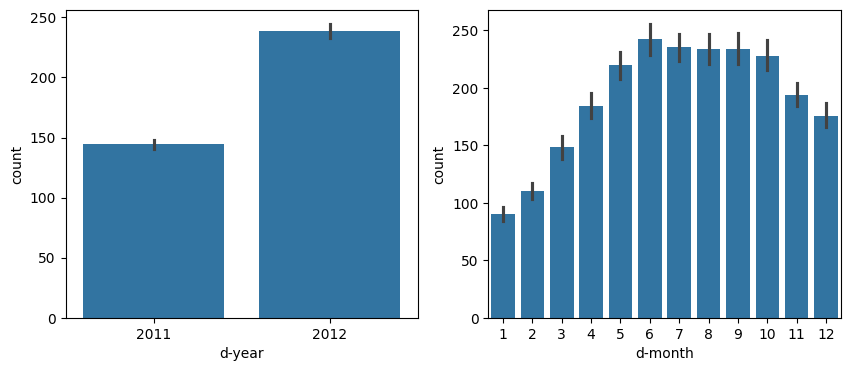

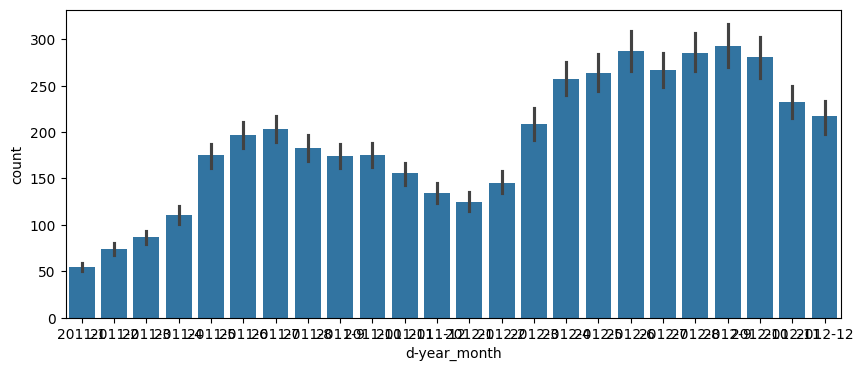

In [43]:
figure, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
figure.set_size_inches(10, 4)

sns.barplot(data=train, x="d-year", y="count", ax=ax1)
sns.barplot(data=train, x="d-month", y="count", ax=ax2)

figure, ax3 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(10, 4)

sns.barplot(data=train, x="d-year_month", y="count", ax=ax3)

## select features to use for training

In [44]:
train.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'd-year', 'd-month', 'd-day', 'd-hour', 'd-minute', 'd-second',
       'd-dayofweek', 'd-year_month'],
      dtype='object')

In [45]:
features = ["season", "holiday", "workingday", "weather",
            "temp", "atemp", "humidity", "windspeed",
            "d-month", "d-hour", "d-dayofweek"]

In [47]:
X, y = train[features], train['count']
print(X.shape, y.shape)
X.head()

(10886, 11) (10886,)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,d-month,d-hour,d-dayofweek
0,1,0,0,1,9.84,14.395,81,0.0,1,0,5
1,1,0,0,1,9.02,13.635,80,0.0,1,1,5
2,1,0,0,1,9.02,13.635,80,0.0,1,2,5
3,1,0,0,1,9.84,14.395,75,0.0,1,3,5
4,1,0,0,1,9.84,14.395,75,0.0,1,4,5


## A simple prediction model

In [48]:
np.random.seed(11)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

model = RandomForestRegressor(n_estimators= 100)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.876555171753023

- y 의 분포를 보자.

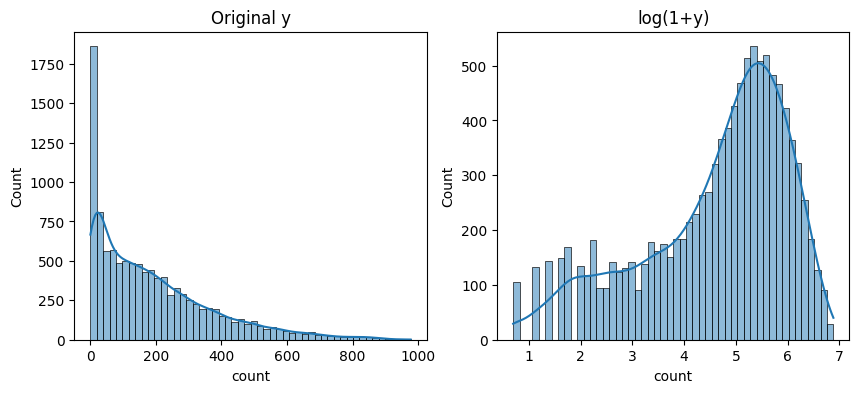

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(y, bins=50, ax=ax[0], kde=True)
ax[0].set_title('Original y')

sns.histplot(np.log1p(y), bins=50, ax=ax[1], kde=True)
ax[1].set_title('log(1+y)')

plt.show()

- 원래 y:
오른쪽 꼬리가 매우 김  → 학습이 어려움
- log(1+y):
대칭적인 분포에 가까움 → 학습이 쉬움

- data transformation (log transform)
  - 정규분포에 가깝게 만들수록 좋은 경우가 많다.

In [49]:
from sklearn.metrics import mean_squared_error
np.random.seed(11)
X_train, X_test, y_train, y_test = train_test_split(X, np.log(1+y), test_size = 0.2)   # y -> log(1 + y)

model = RandomForestRegressor(n_estimators= 100)
model.fit(X_train, y_train)
print("score: ", model.score(X_test, y_test))
print("MSE: ", mean_squared_error(y_test, model.predict(X_test)))

score:  0.9346790888550045
MSE:  0.1301943380618015


- we can see that log(1+y) gives better performance than y.

## other models: linear and decision tree models

In [56]:
model = LinearRegression()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

model = DecisionTreeRegressor()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.4463106099758152
0.8773973607830715


#### change the performance metric (rmse --> rmsle)
- RMSLE(Root Mean Squared Logarithmic Error)
- robust to outliers
- RMSLE는 로그 공간에서 계산한 RMSE로, 절대 오차보다 상대 오차(몇 배 차이)를 평가하며 큰 값의 영향력을 줄여 long-tail 데이터를 다루기에 적합한 지표이다. (logA - logB = log(A/B))
- to be used in GridSearch()
- $$ \sqrt{\frac{1}{n} \sum_{i=1}^n (\log(p_i + 1) - \log(a_i+1))^2 } $$

In [58]:
def rmsle(predict, actual):
    predict = np.array(predict)
    actual = np.array(actual)

    predict = np.log(predict + 1)
    actual = np.log(actual + 1)

    difference_square_mean = np.square(predict - actual).mean()
    score = np.sqrt(difference_square_mean)
    return score

rmsle_scorer = make_scorer(rmsle)    #  make your own scoring function
rmsle_scorer

make_scorer(rmsle, response_method='predict')

## selecting hyperparameters
- Grid search
- Random search

##### Grid search

In [59]:
# Grid Search for the random forest

n_estimators = 300

max_depth_list = [10, 20, 30, 50, 100]
max_features_list = [0.1, 0.3, 0.5, 0.7,  0.9]

hyperparameters_list = []

for max_depth in max_depth_list:
    for max_features in max_features_list:
        model = RandomForestRegressor(n_estimators=n_estimators,
                                      max_depth=max_depth,
                                      max_features=max_features,
                                      random_state=11,
                                      n_jobs=-1)

        score = cross_val_score(model, X_train, y_train, cv=5,
                                scoring=rmsle_scorer).mean()

        hyperparameters_list.append({
            'score': score,
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'max_features': max_features,
        })

        print("Score = {0:.5f}".format(score))

hyperparameters_list

Score = 0.17114
Score = 0.12478
Score = 0.10455
Score = 0.09924
Score = 0.09777
Score = 0.14110
Score = 0.10830
Score = 0.09687
Score = 0.09472
Score = 0.09476
Score = 0.14093
Score = 0.10856
Score = 0.09674
Score = 0.09463
Score = 0.09469
Score = 0.14093
Score = 0.10855
Score = 0.09673
Score = 0.09464
Score = 0.09471
Score = 0.14093
Score = 0.10855
Score = 0.09673
Score = 0.09464
Score = 0.09471


[{'score': np.float64(0.17114038275739257),
  'n_estimators': 300,
  'max_depth': 10,
  'max_features': 0.1},
 {'score': np.float64(0.12477708227092824),
  'n_estimators': 300,
  'max_depth': 10,
  'max_features': 0.3},
 {'score': np.float64(0.1045481397405857),
  'n_estimators': 300,
  'max_depth': 10,
  'max_features': 0.5},
 {'score': np.float64(0.09924420216874322),
  'n_estimators': 300,
  'max_depth': 10,
  'max_features': 0.7},
 {'score': np.float64(0.09776712062842981),
  'n_estimators': 300,
  'max_depth': 10,
  'max_features': 0.9},
 {'score': np.float64(0.1411042098916346),
  'n_estimators': 300,
  'max_depth': 20,
  'max_features': 0.1},
 {'score': np.float64(0.10829789263605001),
  'n_estimators': 300,
  'max_depth': 20,
  'max_features': 0.3},
 {'score': np.float64(0.09686738602894093),
  'n_estimators': 300,
  'max_depth': 20,
  'max_features': 0.5},
 {'score': np.float64(0.09471809866190518),
  'n_estimators': 300,
  'max_depth': 20,
  'max_features': 0.7},
 {'score': n

In [60]:
hyperparameters_list = pd.DataFrame.from_dict(hyperparameters_list)  # make dataframe from dictionary
hyperparameters_list = hyperparameters_list.sort_values(by="score")

print(hyperparameters_list.shape)
hyperparameters_list.head()

(25, 4)


,score,n_estimators,max_depth,max_features
13,0.094635,300,30,0.7
18,0.094639,300,50,0.7
23,0.094639,300,100,0.7
14,0.094692,300,30,0.9
24,0.094706,300,100,0.9


##### Random search
- 2 stages: random selection and fine tuning

In [61]:
# Random selection

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

hyperparameters_list = []

n_estimators = 30
num_epoch = 10

for epoch in range(num_epoch):
    max_depth = np.random.randint(low=2, high=100)
    max_features = np.random.uniform(low=0.1, high=1.0)

    model = RandomForestRegressor(n_estimators=n_estimators,
                                  max_depth=max_depth,
                                  max_features=max_features,
                                  random_state=37,
                                  n_jobs=-1)

    score = cross_val_score(model, X_train, y_train, cv=5,
                            scoring=rmsle_scorer).mean()

    hyperparameters_list.append({
        'score': score,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'max_features': max_features,
    })

    print("Score = {0:.5f}".format(score))

hyperparameters_list = pd.DataFrame.from_dict(hyperparameters_list)
hyperparameters_list = hyperparameters_list.sort_values(by="score")

print(hyperparameters_list.shape)
hyperparameters_list.head()

Score = 0.09661
Score = 0.09754
Score = 0.10312
Score = 0.09754
Score = 0.09678
Score = 0.09614
Score = 0.09877
Score = 0.09754
Score = 0.09754
Score = 0.13336
(10, 4)


,score,n_estimators,max_depth,max_features
5,0.096139,30,79,0.981396
0,0.096608,30,26,0.908559
4,0.096780,30,91,0.904707
1,0.097536,30,84,0.577577
7,0.097536,30,62,0.579520


In [62]:
X_train.shape

(8708, 11)

In [63]:
# fine search

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

hyperparameters_list = []

n_estimators = 30
num_epoch = 10

for epoch in range(num_epoch):
    max_depth = np.random.randint(low=30, high=90)
    max_features = np.random.uniform(low=0.5, high=1.0)

    model = RandomForestRegressor(n_estimators=n_estimators,
                                  max_depth=max_depth,
                                  max_features=max_features,
                                  random_state=37,
                                  n_jobs=-1)

    score = cross_val_score(model, X_train, y_train, cv=5,
                            scoring=rmsle_scorer).mean()

    hyperparameters_list.append({
        'score': score,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'max_features': max_features,
    })

    print("Score = {0:.5f}".format(score))

hyperparameters_list = pd.DataFrame.from_dict(hyperparameters_list)
hyperparameters_list = hyperparameters_list.sort_values(by="score")

print(hyperparameters_list.shape)
hyperparameters_list

Score = 0.09877
Score = 0.09624
Score = 0.09614
Score = 0.09754
Score = 0.09624
Score = 0.09604
Score = 0.09624
Score = 0.09614
Score = 0.09624
Score = 0.09877
(10, 4)


,score,n_estimators,max_depth,max_features
5,0.096043,30,31,0.677956
2,0.096139,30,81,0.966159
7,0.096139,30,51,0.924424
1,0.096245,30,71,0.801307
4,0.096245,30,74,0.742654
6,0.096245,30,44,0.747706
8,0.096245,30,49,0.778156
3,0.097536,30,69,0.635713
0,0.098767,30,79,0.507058
9,0.098767,30,41,0.503748


In [64]:
# final selection of hyperparameters (최종모델 선택)

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=300,
                              max_depth=65,
                              max_features=0.9309,
                              random_state=37,
                              n_jobs=-1)
model.fit(X_train, y_train)
score = cross_val_score(model, X_train, y_train, cv=5,
                        scoring=rmsle_scorer).mean()
print("Score = {0:.5f}".format(score))

Score = 0.09492


#### Most significant features

In [65]:
model.feature_importances_    # he higher, the more important the feature.

array([0.00875075, 0.00165887, 0.03698031, 0.01170928, 0.05059109,
       0.03217508, 0.03006855, 0.01550813, 0.03017972, 0.75209263,
       0.0302856 ])

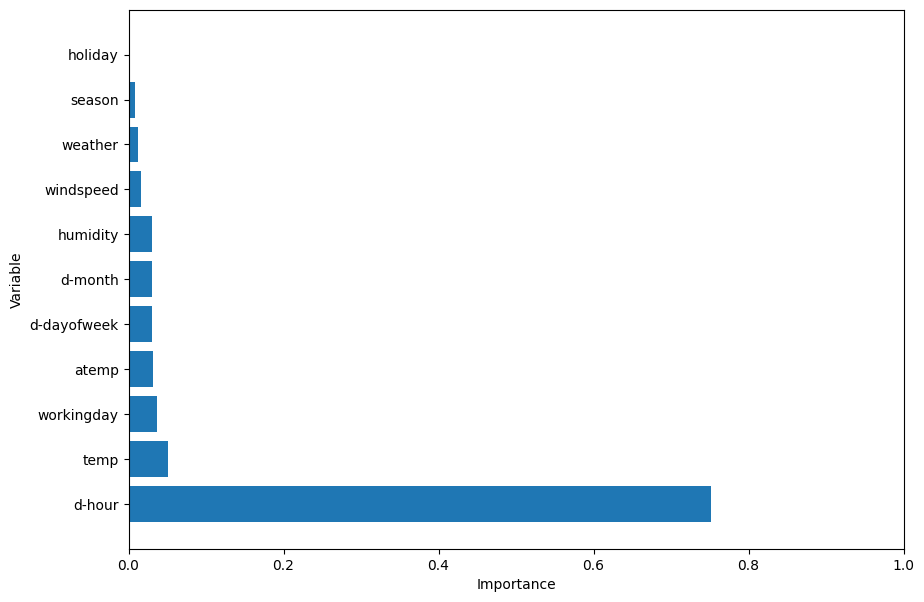

In [66]:
df = pd.DataFrame({'feature':features,'importance':model.feature_importances_ })
df=df.sort_values('importance', ascending=False)
x = df.feature
y = df.importance
ypos = np.arange(len(x))
plt.figure(figsize=(10,7))
plt.barh(x, y)
plt.yticks(ypos, x)
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.xlim(0, 1)
plt.ylim(-1, len(x))
plt.show()

In [ ]:
## GridSearchCV() function

In [67]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8708, 11) (2178, 11) (8708,) (2178,)


In [68]:
rcf = RandomForestRegressor(n_estimators=100)
rcf.fit(X_train, y_train)
rcf.score(X_test, y_test)

0.9355011834015486

# GridSearchCV()
- 그리드 탐색을 하며 동시에 교차 검증 수행
- fit, model, score 함수를 제공하며 fit 를 호출할 때 여러 파라미터 조합에 대해 교차 검증을 수행
- Exhaustive search over specified parameter values for an estimator.
- it implements a “fit” and a “score” method. It also implements “predict”, “predict_proba”, “decision_function”,
 “transform” and “inverse_transform” if they are implemented in the estimator used.
- The parameters of the estimator used to apply these methods are optimized by cross-validated grid-search over a parameter grid.
- 그리드 탐색과 교차 검증을 동시에 수행

In [ ]:
from sklearn.model_selection import GridSearchCV

params = [{"max_depth":[10, 20, 30],
           "max_features":[0.3, 0.5, 0.9]}]

# grid search
clf = GridSearchCV(RandomForestRegressor(), params, cv=3, n_jobs=-1)
clf.fit(X_train, y_train)
print("best values: ", clf.best_estimator_)
print("best score: ", clf.best_score_)

# final evaluation on test data
score = clf.score(X_test, y_test)
print("final score: ", score)

best values:  RandomForestRegressor(max_depth=30, max_features=0.9)
best score:  0.9464801835827675
final score:  0.9590798119239151


# RandomizedSearchCV() function
- In contrast to GridSearchCV, not all parameter values are tried out, but rather a fixed number
of parameter settings is sampled from the specified distributions. The number of parameter settings
that are tried is given by n_iter.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
max_features = ['auto', 'sqrt']  # log2
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

rf = RandomizedSearchCV(RandomForestRegressor(), random_grid,
                               cv = 3, n_jobs = -1) # n_iter default 10
# Fit the random search model
rf.fit(X_train, y_train)

print(rf.best_params_, rf.best_estimator_, rf.best_score_)
score = rf.score(X_test, y_test)
print(score)

/usr/local/lib/python3.7/dist-packages/joblib/externals/loky/process_executor.py:703: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  "timeout or by a memory leak.", UserWarning


{'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'auto', 'max_depth': 100, 'bootstrap': True} RandomForestRegressor(max_depth=100, min_samples_leaf=2, n_estimators=600) 0.9465479780903824
0.9591829180036772
